In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
data = pd.DataFrame(columns=['concentrations', 'fluorescence1', 'fluorescence2'])
data['concentrations'] = [8,2,1.6,0.4,0.32,0.08,0.064,0.016]
data['fluorescence1'] = [3822, 417, 426, 95, 79, 16, 14, 2]
data['fluorescence2'] = [4284, 407, 424, 83, 88, 15, 16, 5]
data.set_index('concentrations', inplace=True)
data

,fluorescence1,fluorescence2
concentrations,,
8.000,3822,4284
2.000,417,407
1.600,426,424
0.400,95,83
0.320,79,88
0.080,16,15
0.064,14,16
0.016,2,5


In [88]:
degree = 2
ymeans = (data['fluorescence1'] + data['fluorescence2']) / 2
co, residuals, rank, s, rcond = np.polyfit(data.index, ymeans, deg=degree, full=True)

ypred = np.poly1d(co)(data.index)

sst = np.sum((ymeans-np.mean(ymeans))**2)
ssr = np.sum((ymeans-ypred)**2)
r2 = 1 - (ssr/sst)

print(degree, r2)

2 0.9992661018690223


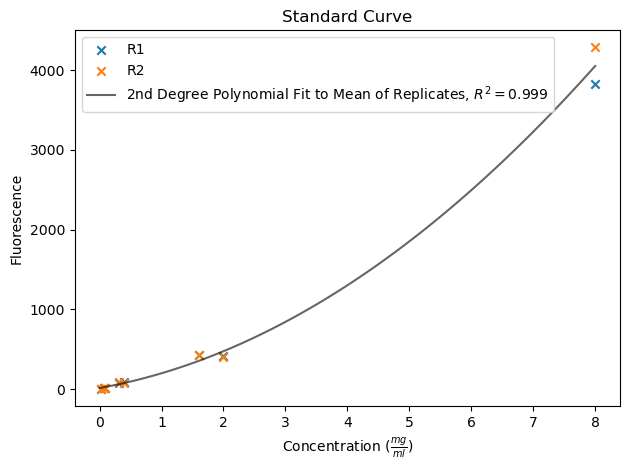

In [105]:
fig, ax = plt.subplots()
ax.scatter(data.index, data['fluorescence1'], marker='x', label='R1')
ax.scatter(data.index, data['fluorescence2'], marker='x', label='R2')
ax.plot(np.linspace(0,8,100), np.poly1d(co)(np.linspace(0,8,100)), label=r'2nd Degree Polynomial Fit to Mean of Replicates, $R^2=$'+str(round(r2, 3)), color='k', alpha=0.6)
ax.set_ylabel('Fluorescence')
ax.set_xlabel(r'Concentration ($\frac{mg}{ml}$)')
# ax.set_yscale('log')
ax.set_title('Standard Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [94]:
samples = pd.DataFrame(columns=['x1pred','x2pred', 'x3pred', 'y1', 'y2', 'y3'])
samples['y1'] = [4402, 4103, 7493]
samples['y2'] = [2354, 4355, 9345]
samples['y3'] = [1161, 4734, 8559]

for y in [1, 2, 3]:
    for i, val in samples.iterrows(): 
        sol_coefficients = co.copy()
        sol_coefficients[-1] = co[-1] - samples.loc[i,'y'+str(y)]
        p = np.roots(sol_coefficients)
        for x in p: 
            if x > 0 and x != np.nan: 
                samples.loc[i,'x'+str(y)+'pred'] = x
samples

,x1pred,x2pred,x3pred,y1,y2,y3
0,8.394495,5.792024,3.710445,4402,2354,1161
1,8.058697,8.342468,8.754512,4103,4355,4734
2,11.363028,12.850951,12.239126,7493,9345,8559


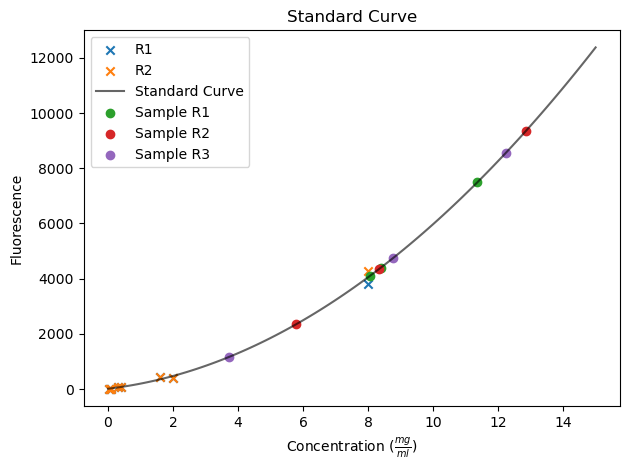

In [107]:
fig, ax = plt.subplots()

ypred_long = np.poly1d(co)(np.linspace(0,15,100))

ax.scatter(data.index, data['fluorescence1'], marker='x', label='R1')
ax.scatter(data.index, data['fluorescence2'], marker='x', label='R2')
ax.plot(np.linspace(0,15,100), ypred_long, label=r'Standard Curve', color='k', alpha=0.6)

ax.scatter(samples['x1pred'], samples['y1'], marker='o', label='Sample R1')
ax.scatter(samples['x2pred'], samples['y2'], marker='o', label='Sample R2')
ax.scatter(samples['x3pred'], samples['y3'], marker='o', label='Sample R3')

ax.set_ylabel('Fluorescence')
ax.set_xlabel(r'Concentration ($\frac{mg}{ml}$)')
# ax.set_yscale('log')
ax.set_title('Standard Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [108]:
samples = pd.DataFrame(columns=['x1pred','x2pred', 'x3pred', 'y1', 'y2', 'y3'])
samples['y1'] = [4402, 2354, 1161]
samples['y2'] = [4103, 4355, 4734]
samples['y3'] = [7493, 9345, 8559]

for y in [1, 2, 3]:
    for i, val in samples.iterrows(): 
        sol_coefficients = co.copy()
        sol_coefficients[-1] = co[-1] - samples.loc[i,'y'+str(y)]
        p = np.roots(sol_coefficients)
        for x in p: 
            if x > 0 and x != np.nan: 
                samples.loc[i,'x'+str(y)+'pred'] = x
samples

,x1pred,x2pred,x3pred,y1,y2,y3
0,8.394495,8.058697,11.363028,4402,4103,7493
1,5.792024,8.342468,12.850951,2354,4355,9345
2,3.710445,8.754512,12.239126,1161,4734,8559


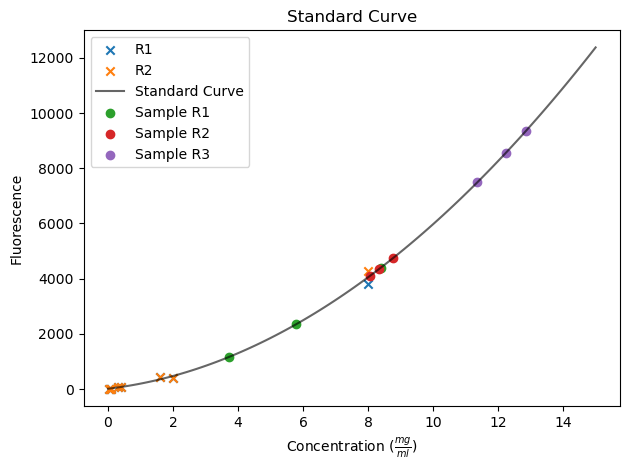

In [109]:
fig, ax = plt.subplots()

ypred_long = np.poly1d(co)(np.linspace(0,15,100))

ax.scatter(data.index, data['fluorescence1'], marker='x', label='R1')
ax.scatter(data.index, data['fluorescence2'], marker='x', label='R2')
ax.plot(np.linspace(0,15,100), ypred_long, label=r'Standard Curve', color='k', alpha=0.6)

ax.scatter(samples['x1pred'], samples['y1'], marker='o', label='Sample R1')
ax.scatter(samples['x2pred'], samples['y2'], marker='o', label='Sample R2')
ax.scatter(samples['x3pred'], samples['y3'], marker='o', label='Sample R3')

ax.set_ylabel('Fluorescence')
ax.set_xlabel(r'Concentration ($\frac{mg}{ml}$)')
# ax.set_yscale('log')
ax.set_title('Standard Curve')
ax.legend()
plt.tight_layout()
plt.show()